# Regression Plots Examples

This notebook demonstrates the usage of the RegressionPlots class methods with sklearn datasets and models. The RegressionPlots class provides comprehensive visualization tools for regression model evaluation and analysis.

In [11]:
import numpy as np
from sklearn.datasets import make_regression, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from kvbiii_plots.evaluation.regression_plots import RegressionPlots

In [12]:
# Initialize the RegressionPlots class
reg_plots = RegressionPlots()

# Display available metrics
print("Available metrics:", list(reg_plots.metrics_dict.keys()))
print("Default regression colors:", reg_plots.default_regression_colors)

Available metrics: ['Accuracy', 'Balanced Accuracy', 'F1', 'F1 (Micro)', 'F1 (Macro)', 'F1 (Weighted)', 'Recall', 'Precision', 'Roc AUC', 'MAE', 'MAPE', 'MSE', 'RMSE', 'RMSLE', 'R2']
Default regression colors: {'scatter': 'rgba(0, 123, 255, 0.7)', 'line': 'rgba(220, 53, 69, 0.85)', 'trendline': 'rgba(40, 167, 69, 0.85)', 'residual_line': 'rgba(220, 53, 69, 0.85)'}


## Generate Sample Data and Train Models

We'll create different datasets and train multiple models to demonstrate various regression plotting scenarios.

In [13]:
# Set random seed for reproducibility
np.random.seed(42)

# Dataset 1: Simple synthetic regression data
X_simple, y_simple = make_regression(n_samples=300, n_features=1, noise=15, random_state=42)
X_simple_train, X_simple_test, y_simple_train, y_simple_test = train_test_split(
    X_simple, y_simple, test_size=0.3, random_state=42
)

# Dataset 2: Multi-feature synthetic data with higher noise
X_multi, y_multi = make_regression(n_samples=500, n_features=5, noise=25, random_state=42)
X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi, y_multi, test_size=0.3, random_state=42
)

# Dataset 3: Diabetes dataset (real-world data)
diabetes = load_diabetes()
X_diabetes, y_diabetes = diabetes.data, diabetes.target
X_diabetes_train, X_diabetes_test, y_diabetes_train, y_diabetes_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.3, random_state=42
)

print("Dataset shapes:")
print(f"Simple regression: Train {X_simple_train.shape}, Test {X_simple_test.shape}")
print(f"Multi-feature: Train {X_multi_train.shape}, Test {X_multi_test.shape}")
print(f"Diabetes: Train {X_diabetes_train.shape}, Test {X_diabetes_test.shape}")

Dataset shapes:
Simple regression: Train (210, 1), Test (90, 1)
Multi-feature: Train (350, 5), Test (150, 5)
Diabetes: Train (309, 10), Test (133, 10)


In [14]:
# Train different models for comparison
models = {}

# Linear Regression on simple data
models['lr_simple'] = LinearRegression()
models['lr_simple'].fit(X_simple_train, y_simple_train)

# Linear Regression on multi-feature data
models['lr_multi'] = LinearRegression()
models['lr_multi'].fit(X_multi_train, y_multi_train)

# Random Forest on multi-feature data
models['rf_multi'] = RandomForestRegressor(n_estimators=100, random_state=42)
models['rf_multi'].fit(X_multi_train, y_multi_train)

# Ridge Regression on diabetes data
models['ridge_diabetes'] = Ridge(alpha=1.0, random_state=42)
models['ridge_diabetes'].fit(X_diabetes_train, y_diabetes_train)

# Random Forest on diabetes data
models['rf_diabetes'] = RandomForestRegressor(n_estimators=100, random_state=42)
models['rf_diabetes'].fit(X_diabetes_train, y_diabetes_train)

# Generate predictions
predictions = {}
predictions['lr_simple'] = models['lr_simple'].predict(X_simple_test)
predictions['lr_multi'] = models['lr_multi'].predict(X_multi_test)
predictions['rf_multi'] = models['rf_multi'].predict(X_multi_test)
predictions['ridge_diabetes'] = models['ridge_diabetes'].predict(X_diabetes_test)
predictions['rf_diabetes'] = models['rf_diabetes'].predict(X_diabetes_test)

print("Models trained and predictions generated!")

Models trained and predictions generated!


## 1. homoscedacity_plot() - Residuals vs Fitted Values

The homoscedacity plot helps assess whether the residuals have constant variance across fitted values. This is crucial for validating linear regression assumptions.

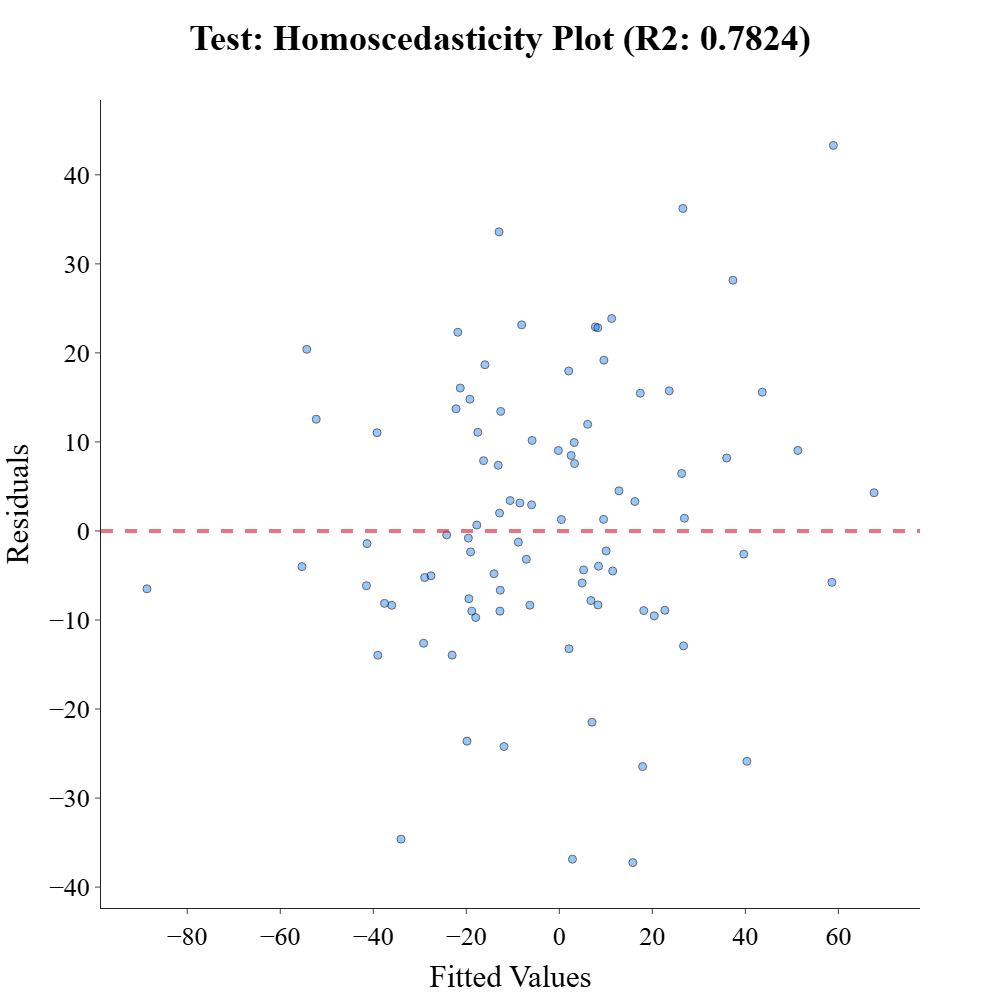

In [15]:
reg_plots.homoscedacity_plot(
    y_true=y_simple_test,
    y_pred=predictions['lr_simple'],
    plot_title=f"Test: Homoscedasticity Plot",
    metric_name="R2",
)

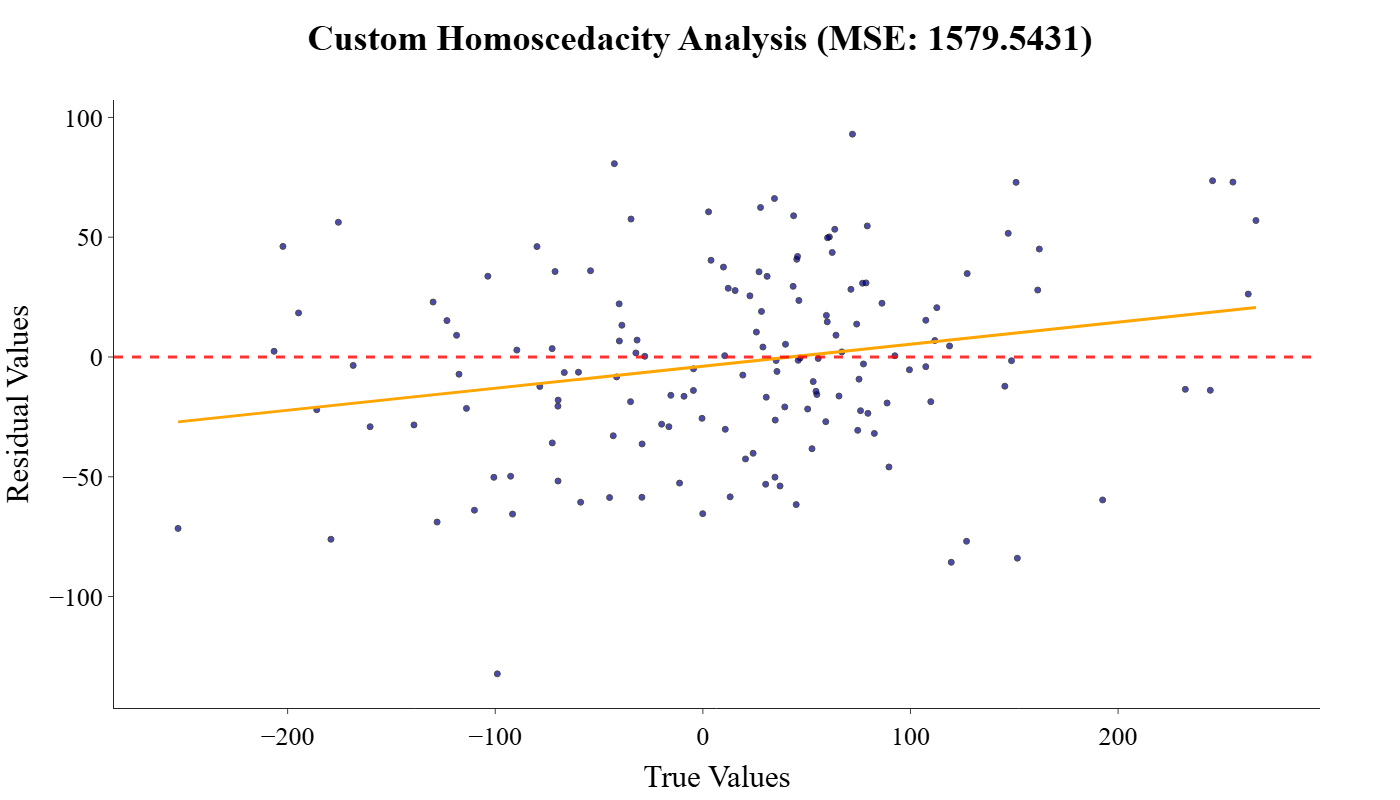

In [16]:
reg_plots.homoscedacity_plot(
    y_true=y_multi_test,
    y_pred=predictions['rf_multi'],
    plot_title="Custom Homoscedacity Analysis",
    width=1400,
    height=800,
    xaxis_title="True Values",
    yaxis_title="Residual Values",
    metric_name="MSE",
    scatter_color="darkblue",
    scatter_size=6,
    scatter_opacity=0.7,
    reference_line_color="red",
    reference_line_width=3,
    show_trendline=True,
    trendline_color="orange"
)

## 2. true_vs_fitted_plot() - Prediction Accuracy Assessment

This plot compares true values against predicted values. Points close to the diagonal line indicate better predictions.

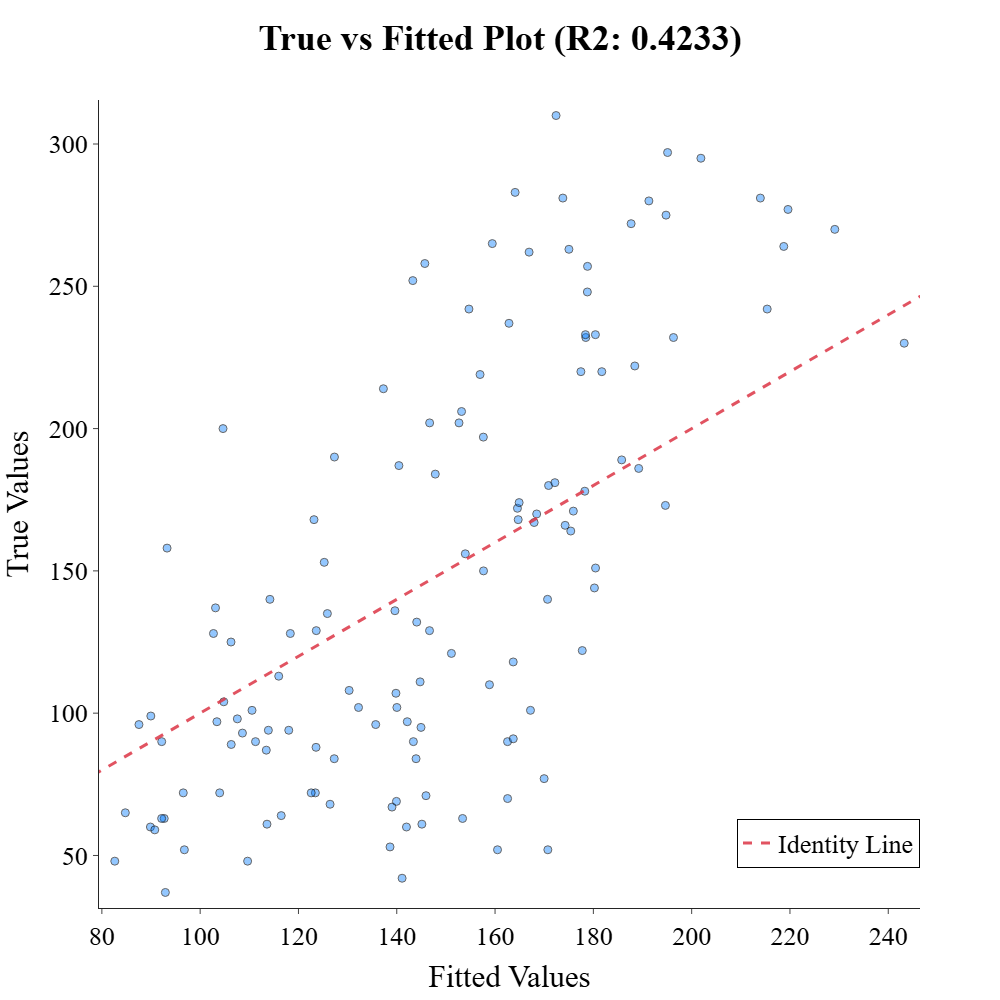

In [17]:
reg_plots.true_vs_fitted_plot(
    y_true=y_diabetes_test,
    y_pred=predictions['ridge_diabetes'],
    metric_name="R2",
)

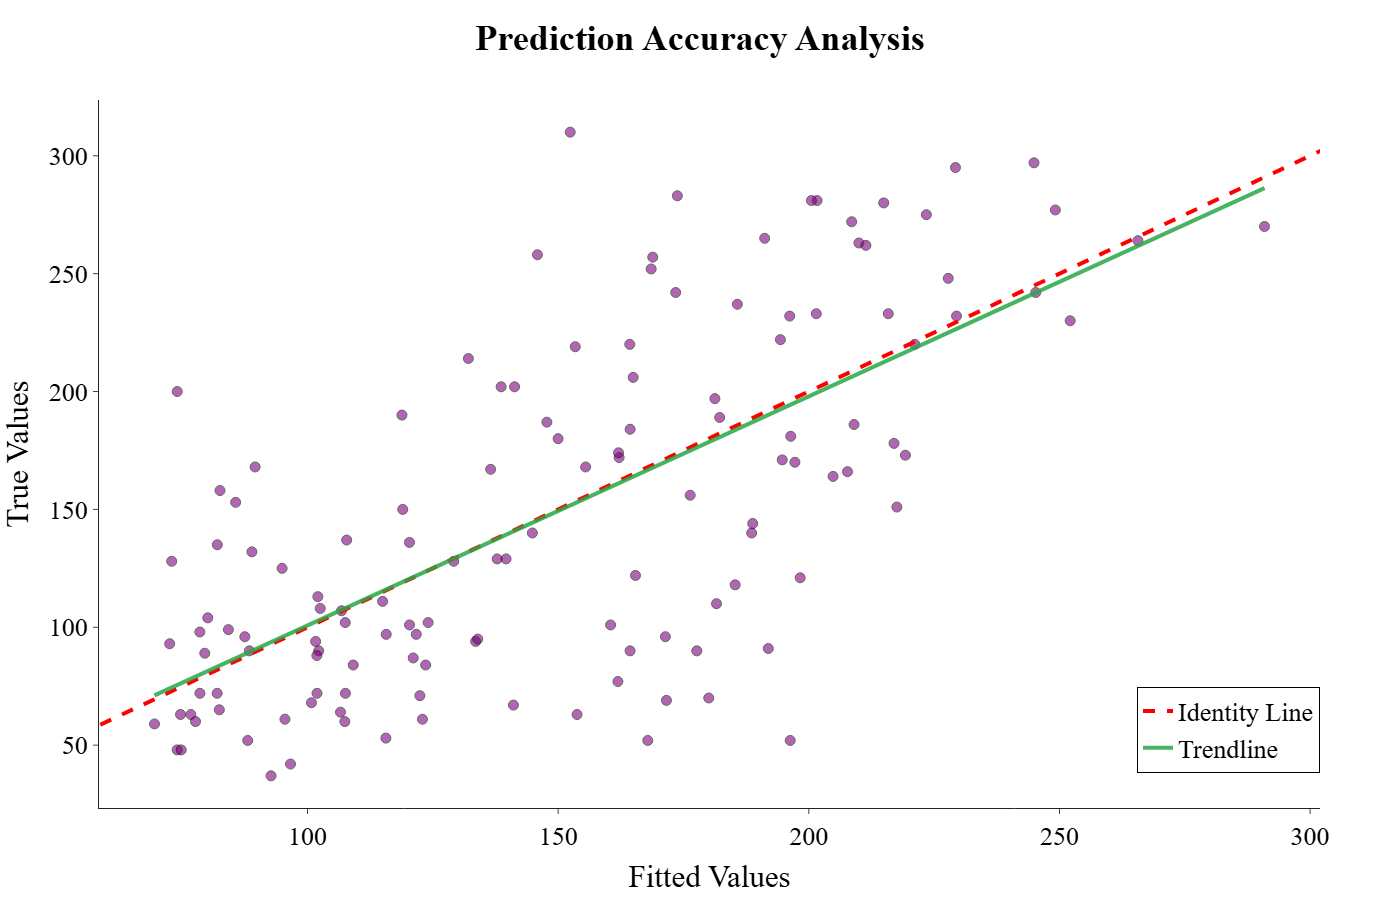

In [18]:
reg_plots.true_vs_fitted_plot(
    y_true=y_diabetes_test,
    y_pred=predictions['rf_diabetes'],
    plot_title="Prediction Accuracy Analysis",
    width=1400,
    height=900,
    xaxis_title="Fitted Values",
    yaxis_title="True Values",
    metric_name="MAE",
    scatter_color="purple",
    scatter_size=10,
    scatter_opacity=0.6,
    show_diagonal=True,
    diagonal_color="red",
    diagonal_width=4,
    show_trendline=True,
    trendline_width=4,
    axis_buffer_percent=5.0
)

## 3. residual_distribution_plot() - Residual Normality Assessment

This plot helps assess whether residuals follow a normal distribution, which is an important assumption for many regression models.

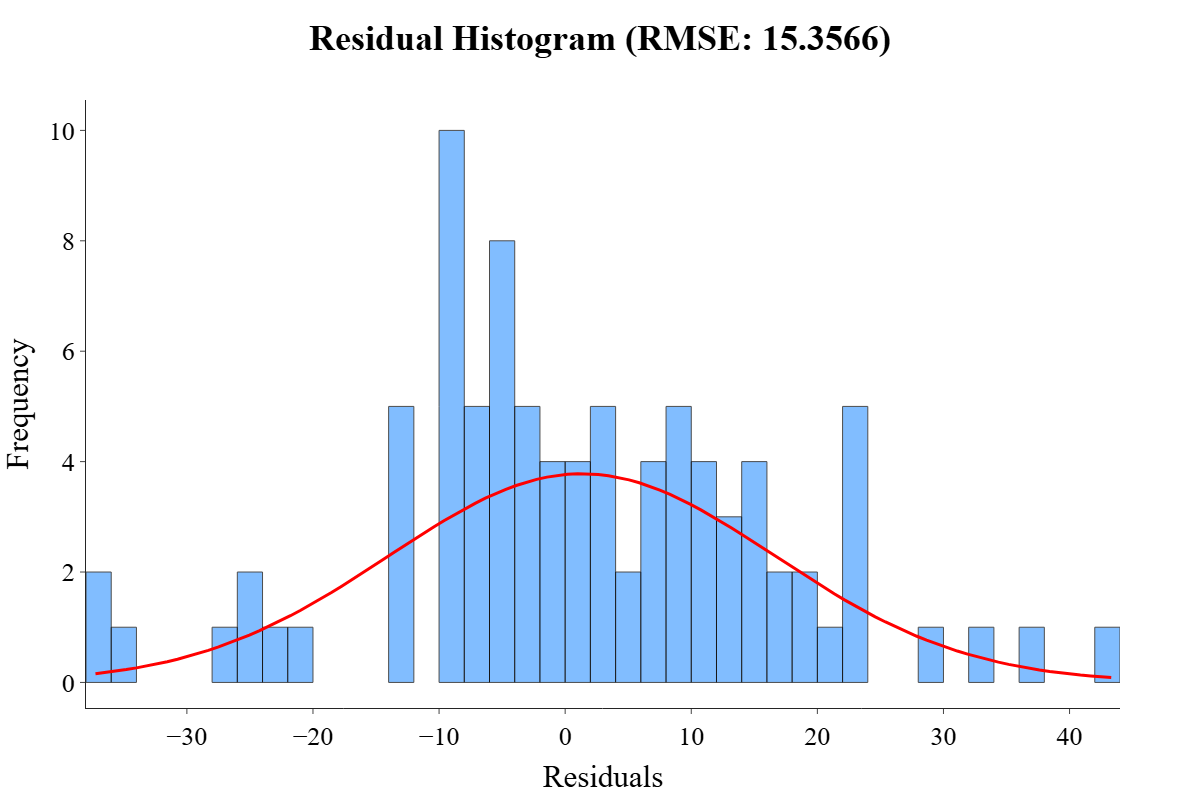

In [19]:
reg_plots.residual_distribution_plot(
    y_true=y_simple_test,
    y_pred=predictions['lr_simple'],
    plot_type="histogram",
)

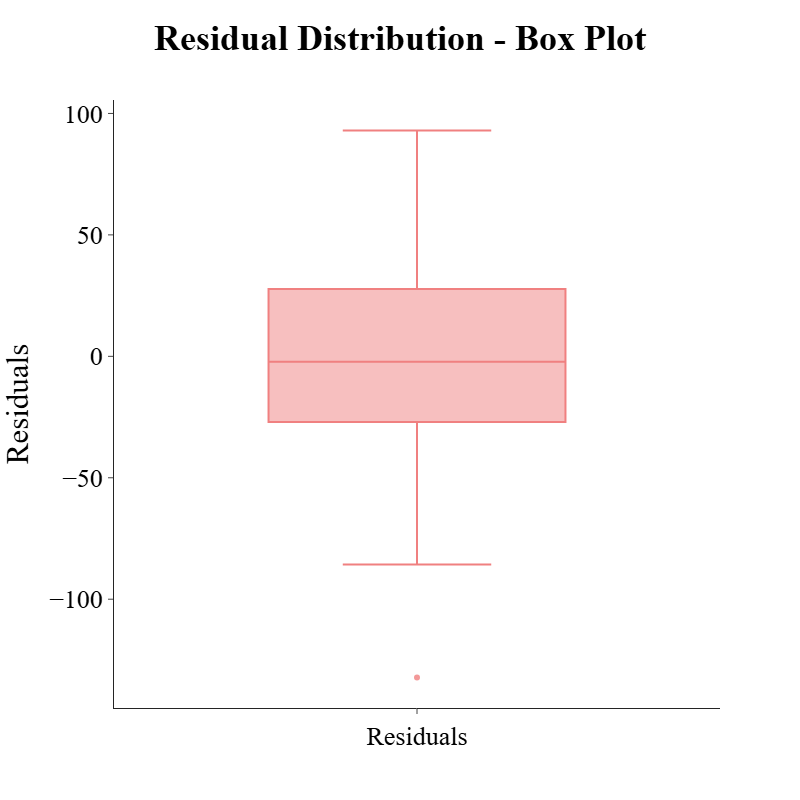

In [20]:
reg_plots.residual_distribution_plot(
    y_true=y_multi_test,
    y_pred=predictions['rf_multi'],
    plot_type="box",
    metric_name="MAE",
    plot_title="Residual Distribution - Box Plot",
    width=800,
    height=800,
    color="lightcoral",
    opacity=0.8
)